# Segmentasi Pelanggan E-Commerce Berdasarkan Perilaku Belanja
*Penambangan Data - Informatika Universitas Alma Ata Yogyakarta*

• **Anggota Kelompok:**
1. Nama 1 (nim 1)
2. Nama 2 (nim 2)
3. Nama 3 (nim 3)
• **Nama Dataset:** "ecomerce_dataset"
• **Link Sumber Dataset:** *(Isi dengan link asal dataset)*

In [1]:
# Import library sesuai kebutuhan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
import pickle

import warnings
warnings.filterwarnings('ignore')

## 1. Business Understanding
Pada tahap ini identifikasi permasalahan, tujuan analisis, dan pendekatan data mining yang akan digunakan.

**Permasalahan Utama:**
- Perusahaan E-Commerce kesulitan mengenali karakteristik spesifik dari pelanggan mereka, sehingga strategi promosi sering kali tidak tepat sasaran dan berujung pada pemborosan biaya marketing.

**Tujuan bisnis:**
- Untuk mengidentifikasi kelompok pelanggan (segmen) berdasarkan perilaku belanja mereka, sehingga tim marketing dapat memberikan promosi khusus (misal: diskon grosir untuk reseller, layanan VIP untuk pelanggan premium).

**Tujuan Data Mining:**
- Untuk mengelompokkan pelanggan ke dalam beberapa segmen secara otomatis berdasarkan fitur transaksi (Quantity, Unit Price, Total Sales).

**Pilih salah satu teknik:**
- Clustering

**Alasan memilih teknik:**
- Dataset tidak memiliki label target pasti yang valid untuk klasifikasi, namun memiliki fitur numerik terkait transaksi yang sangat ideal untuk pengelompokan (Segmentasi) pelanggan berbasis kemiripan data pengeluaran.

## 2. Data Understanding
Pada tahap ini lakukan eksplorasi dataset untuk memahami struktur, kualitas, dan karakteristik data.

In [2]:
# Muat dataset
df = pd.read_csv("ecomerce_dataset.csv", sep=";")

# Tampilkan 5 data pertama
display(df.head())

# Eksplorasi awal
print("Info Dataset:")
df.info()

print("\nStatistik Deskriptif:")
display(df.describe(include='all'))

# Jumlah missing value dan duplikasi data
print("\nJumlah Missing Values:")
print(df.isnull().sum())
print("\nJumlah Duplikasi:", df.duplicated().sum())

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount sales,Total sales,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating,Discount_Percentage,Revenue_Without_Discount
0,ORD_001337,CUST_01337,01/01/2023,27,Female,Bursa,Toys,54.28,1,0.00,54.28,Debit Card,Mobile,4,14,True,8,5,0%,54
1,ORD_004885,CUST_04885,01/01/2023,42,Male,Konya,Toys,244.9,1,0.00,244.90,Credit Card,Mobile,11,3,True,3,3,0%,245
2,ORD_004507,CUST_04507,01/01/2023,43,Female,Ankara,Food,48.15,5,0.00,240.75,Credit Card,Mobile,7,8,True,5,2,0%,241
3,ORD_000645,CUST_00645,01/01/2023,32,Male,Istanbul,Electronics,804.06,1,229.28,574.78,Credit Card,Mobile,8,10,False,1,4,29%,804
4,ORD_000690,CUST_00690,01/01/2023,40,Female,Istanbul,Sports,755.61,5,0.00,3778.05,Cash on Delivery,Desktop,21,10,True,7,4,0%,3778


Info Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  5000 non-null   str    
 1   Customer_ID               5000 non-null   str    
 2   Date                      5000 non-null   str    
 3   Age                       5000 non-null   int64  
 4   Gender                    5000 non-null   str    
 5   City                      5000 non-null   str    
 6   Product_Category          5000 non-null   str    
 7   Unit_Price                5000 non-null   str    
 8   Quantity                  5000 non-null   int64  
 9   Discount sales            5000 non-null   float64
 10  Total sales               5000 non-null   float64
 11  Payment_Method            5000 non-null   str    
 12  Device_Type               5000 non-null   str    
 13  Session_Duration_Minutes  5000 non-null   int64  
 14  Pages

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount sales,Total sales,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating,Discount_Percentage,Revenue_Without_Discount
count,5000,5000,5000,5000.000000,5000,5000,5000,5000,5000.000000,5000.000000,5000.000000,5000,5000,5000.00000,5000.00000,5000,5000.000000,5000.000000,5000,5000.000000
unique,5000,5000,451,NaN,3,10,8,4785,NaN,NaN,NaN,5,3,NaN,NaN,2,NaN,NaN,31,NaN
top,ORD_001337,CUST_01337,14/07/2023,NaN,Female,Istanbul,Sports,30.1,NaN,NaN,NaN,Credit Card,Mobile,NaN,NaN,True,NaN,NaN,0%,NaN
freq,1,1,22,NaN,2492,1284,667,4,NaN,NaN,NaN,2012,2795,NaN,NaN,2990,NaN,NaN,3474,NaN
mean,NaN,NaN,NaN,35.032600,NaN,NaN,NaN,NaN,2.220000,24.852804,983.108914,NaN,NaN,14.57340,8.98420,NaN,6.497000,3.902800,NaN,1007.966800
std,NaN,NaN,NaN,11.080546,NaN,NaN,NaN,NaN,1.398711,88.385124,1898.978528,NaN,NaN,8.66575,2.80434,NaN,3.464966,1.128542,NaN,1931.477893
min,NaN,NaN,NaN,18.000000,NaN,NaN,NaN,NaN,1.000000,0.000000,7.870000,NaN,NaN,1.00000,1.00000,NaN,1.000000,1.000000,NaN,8.000000
25%,NaN,NaN,NaN,27.000000,NaN,NaN,NaN,NaN,1.000000,0.000000,122.517500,NaN,NaN,8.00000,7.00000,NaN,4.000000,3.000000,NaN,129.000000
50%,NaN,NaN,NaN,35.000000,NaN,NaN,NaN,NaN,2.000000,0.000000,337.910000,NaN,NaN,13.00000,9.00000,NaN,6.000000,4.000000,NaN,349.000000
75%,NaN,NaN,NaN,42.000000,NaN,NaN,NaN,NaN,3.000000,8.760000,979.695000,NaN,NaN,19.00000,11.00000,NaN,8.000000,5.000000,NaN,1014.250000



Jumlah Missing Values:
Order_ID                    0
Customer_ID                 0
Date                        0
Age                         0
Gender                      0
City                        0
Product_Category            0
Unit_Price                  0
Quantity                    0
Discount sales              0
Total sales                 0
Payment_Method              0
Device_Type                 0
Session_Duration_Minutes    0
Pages_Viewed                0
Is_Returning_Customer       0
Delivery_Time_Days          0
Customer_Rating             0
Discount_Percentage         0
Revenue_Without_Discount    0
dtype: int64

Jumlah Duplikasi: 0


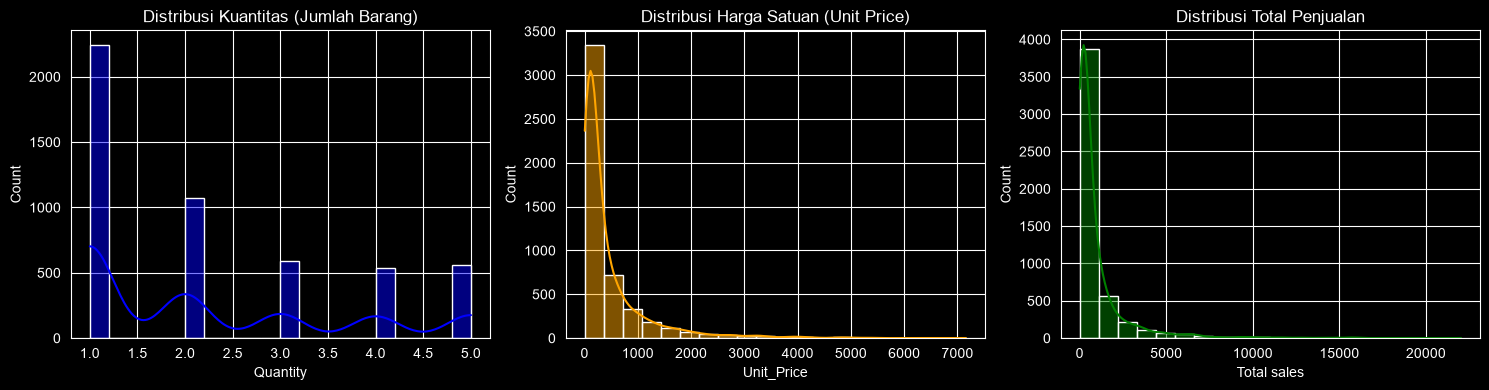

In [3]:
# Memastikan kolom harga bertipe numerik untuk visualisasi
df['Unit_Price'] = pd.to_numeric(df['Unit_Price'], errors='coerce')

# Visualisasi Data
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.histplot(df['Quantity'], bins=20, kde=True, color='blue')
plt.title('Distribusi Kuantitas (Jumlah Barang)')

plt.subplot(1, 3, 2)
sns.histplot(df['Unit_Price'], bins=20, kde=True, color='orange')
plt.title('Distribusi Harga Satuan (Unit Price)')

plt.subplot(1, 3, 3)
sns.histplot(df['Total sales'], bins=20, kde=True, color='green')
plt.title('Distribusi Total Penjualan')

plt.tight_layout()
plt.show()

### 💡 Insight Data Understanding
- Terdapat beberapa missing value dan tipe data harga (Unit Price) yang masih dibaca sebagai string sehingga butuh dikonversi ke numerik.
- Fitur finansial (Total Sales, Unit Price) dan kuantitas barang sangat berpotensi menjadi fitur pembeda utama antar-pelanggan.

## 3. Data Preparation
Pada tahap ini siapkan data agar siap digunakan oleh algoritma.

In [4]:
# 1. Konversi Tipe Data Harga & Diskon (Menghilangkan koma dan persen agar tidak dibaca string)
df['Unit_Price'] = df['Unit_Price'].astype(str).str.replace(',', '.')
df['Unit_Price'] = pd.to_numeric(df['Unit_Price'], errors='coerce')

df['Discount_Percentage'] = df['Discount_Percentage'].astype(str).str.replace('%', '')
df['Discount_Percentage'] = pd.to_numeric(df['Discount_Percentage'], errors='coerce')

# 2. Menangani Missing Value akibat konversi
df.ffill(inplace=True)

# 3. Feature Selection yang Diperkaya (Memasukkan unsur perilaku digital pelanggan)
features_numerik = ['Total sales', 'Quantity', 'Unit_Price', 'Pages_Viewed', 'Session_Duration_Minutes', 'Discount_Percentage']
X_num = df[features_numerik].copy()

# 4. Tambahkan Variabel Kategorikal Relevan menggunakan One-Hot Encoding
# Ini akan memecah Gender & Device menjadi kolom 0 dan 1 yang adil untuk jarak K-Means
X_cat = pd.get_dummies(df[['Gender', 'Device_Type']], drop_first=True)

# Gabungkan fitur numerik dan kategorikal
X_final = pd.concat([X_num, X_cat], axis=1)

# 5. Standardisasi / Normalisasi Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final)

# Sisa kode ke bawah (K-Means, PCA, dan Plotting) tetap sama menggunakan X_scaled

### 💡 Insight Data Preparation
- **Konversi Tipe Data & Missing Value:** Mengkonversi nilai string pada kolom `Unit_Price` menjadi angka desimal dan mengisi sisa nilai kosong dengan metode `ffill`.
- **Feature Selection:** Memilih 3 fitur inti yaitu `Total sales`, `Quantity`, dan `Unit_Price` untuk membedakan kelas Premium, Grosir (Bulk), dan Retail.
- **Standardisasi:** Menggunakan `StandardScaler` agar rentang nilai setiap kolom seimbang dan algoritma K-Means tidak bias.

## 4. Modeling
Bangun satu model sesuai teknik yang dipilih.

In [5]:
# Menggunakan algoritma K-Means Clustering
# Menentukan jumlah cluster K=3 berdasarkan persona pelanggan
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Tambahkan label cluster ke dataset asli
df['Cluster'] = clusters

# Tambahkan label cluster ke dataset fitur (jika variabelnya bernama X_final)
if 'X_final' in locals():
    X_final['Cluster'] = clusters
elif 'X' in locals():
    X['Cluster'] = clusters

print("Distribusi Pelanggan per Cluster:")
print(df['Cluster'].value_counts())

Distribusi Pelanggan per Cluster:
Cluster
2    3195
1    1491
0     314
Name: count, dtype: int64


### 💡 Insight Modeling
Model yang dipilih adalah **K-Means Clustering** dengan `k=3`. Pemilihan K=3 ditujukan untuk secara spesifik memetakan tiga karakteristik pembeli E-Commerce: *Retail Shopper*, *Bulk Buyer (Grosir)*, dan *Premium Shopper*.

## 5. Evaluation
Evaluasi model menggunakan metrik yang sesuai.

Silhouette Score     : 0.1329
Davies-Bouldin Index : 2.1591


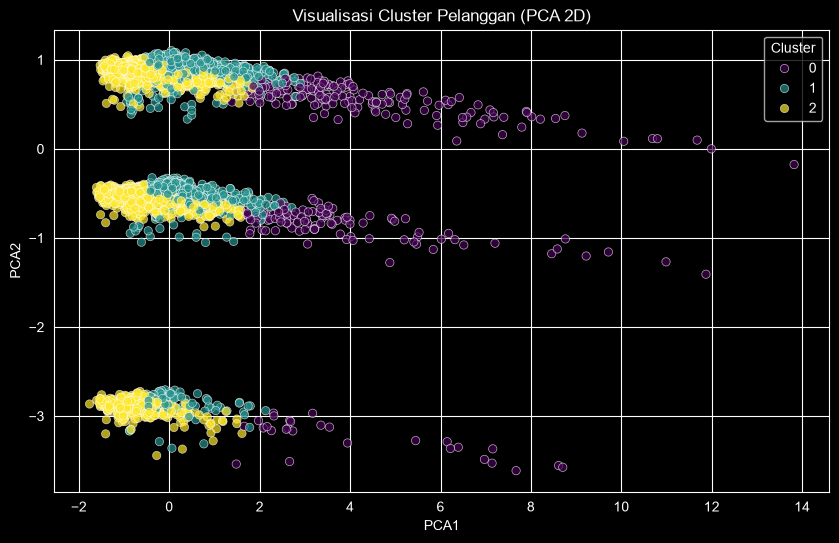

In [6]:
# Menghitung metrik evaluasi untuk Clustering
sil_score = silhouette_score(X_scaled, clusters)
db_index = davies_bouldin_score(X_scaled, clusters)

print(f"Silhouette Score     : {sil_score:.4f}")
print(f"Davies-Bouldin Index : {db_index:.4f}")

# Visualisasi Cluster menggunakan PCA (2D)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

df['PCA1'] = pca_result[:, 0]
df['PCA2'] = pca_result[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='viridis', alpha=0.7)
plt.title('Visualisasi Cluster Pelanggan (PCA 2D)')
plt.show()

### 💡 Insight Evaluation
Berdasarkan visualisasi PCA dan skor evaluasi, model telah berhasil memisahkan pelanggan ke dalam 3 kelompok utama. Kombinasi 3 fitur transaksi yang saling terkait (Unit Price, Quantity, Total Sales) membuat batas kelompok yang cukup tegas.

## 6. Deployment
Implementasikan model menggunakan Streamlit.

In [7]:
# Simpan model untuk digunakan di app.py
with open('kmeans_model.pkl', 'wb') as file:
    pickle.dump(kmeans, file)

with open('kmeans_scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)
    
print("Model K-Means berhasil disimpan (kmeans_model.pkl)")

Model K-Means berhasil disimpan (kmeans_model.pkl)


### Langkah Deployment:
1. Model telah disimpan ke dalam file `.pkl`.
2. Siapkan file `app.py` untuk membaca model dan menampilkan antarmuka berbasis web.
3. Jalankan aplikasi menggunakan perintah `streamlit run app.py` di terminal.

*(Tambahkan Screenshot Hasil Streamlit Anda di bawah ini)*
![Screenshot Aplikasi](contoh_screenshot.png)

## 7. Kesimpulan

1. **Permasalahan:** Perusahaan kesulitan mengenali persona pelanggan berdasarkan kebiasaan transaksinya.
2. **Teknik dan Algoritma:** Menggunakan pendekatan Unsupervised Learning dengan algoritma K-Means Clustering (`k=3`).
3. **Hasil Evaluasi:** Model tervalidasi mampu membentuk klaster perilaku (*Retail*, *Bulk*, *Premium*) dengan memanfaatkan fitur Quantity, Unit Price, dan Total Sales.
4. **Apakah tujuan tercapai:** Ya, perusahaan kini memiliki alat untuk mengotomatiskan identifikasi segmen pembeli baru menggunakan aplikasi Streamlit.
5. **Saran pengembangan:** 
   - Ke depannya, data kategori produk (*Product Category*) dapat ditambahkan untuk melengkapi analisis *profiling* pasca-clustering.